In [1]:
#import packages

In [2]:
import numpy as np
import pandas as pd # used to store and manipulate the data in table form
from datetime import datetime # helps to convert the date strings into the real date objects

In [3]:
data = {
    "application_date": ["2024-01-01", "2024-02-15", "2024-03-10"],
    "decision_date": ["2024-02-01", "2024-03-20", "2024-04-05"],
    "country": ["India", "USA", "UK"],
    "visa_type": ["Student", "Tourist", "Work"]
} # python dict acting like a sample data- 3 data

df = pd.DataFrame(data)
# converts the dict into a Pandas Dataframe, which behaves like a spreadsheet
print(df) # shows a sample datasets as a excel format


  application_date decision_date country visa_type
0       2024-01-01    2024-02-01   India   Student
1       2024-02-15    2024-03-20     USA   Tourist
2       2024-03-10    2024-04-05      UK      Work


In [4]:
# converting the date columns

# these part of the code- converts the date strings "2024-01-01" into an actual datetime objects
# because- we need to calculate the num of days taken for processings

df["application_date"] = pd.to_datetime(df["application_date"])
df["decision_date"] = pd.to_datetime(df["decision_date"])

print(df)

  application_date decision_date country visa_type
0       2024-01-01    2024-02-01   India   Student
1       2024-02-15    2024-03-20     USA   Tourist
2       2024-03-10    2024-04-05      UK      Work


In [5]:
# calculating the processing time

df["processing_days"] = (df["decision_date"] - df["application_date"]).dt.days
# subtracting the dates gives a time difference
#.dt.days-> extracts the differenece in days

print(df)


  application_date decision_date country visa_type  processing_days
0       2024-01-01    2024-02-01   India   Student               31
1       2024-02-15    2024-03-20     USA   Tourist               34
2       2024-03-10    2024-04-05      UK      Work               26


In [6]:
# encoding the categorical features

# learn encoding- is required, and important

# Ml models doesn't understand "India"/"student"-> cinverting te text -> numbers

df_encoded = pd.get_dummies(df, columns=["country", "visa_type"])
#pd.get_dummies -> converts the categorical columns inot 0/1 encoded columns
print(df_encoded)


  application_date decision_date  processing_days  country_India  country_UK  \
0       2024-01-01    2024-02-01               31           True       False   
1       2024-02-15    2024-03-20               34          False       False   
2       2024-03-10    2024-04-05               26          False        True   

   country_USA  visa_type_Student  visa_type_Tourist  visa_type_Work  
0        False               True              False           False  
1         True              False               True           False  
2        False              False              False            True  


In [7]:
X = df_encoded.drop(columns=["processing_days", "application_date", "decision_date"])
y = df_encoded["processing_days"]


In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [9]:
sample_input = {
    "country_India": 1,
    "country_UK": 0,
    "country_USA": 0,
    "visa_type_Student": 1,
    "visa_type_Tourist": 0,
    "visa_type_Work": 0
}

import numpy as np
sample_array = np.array(list(sample_input.values())).reshape(1, -1)

predicted_days = model.predict(sample_array)
print("Predicted Processing Time:", predicted_days[0], "days")


Predicted Processing Time: 31.0 days


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
data = {
    "application_date": ["2024-01-01", None, "2024-03-10"],
    "decision_date": ["2024-02-01", "2024-03-20", None],
    "country": ["India", None, "UK"],
    "visa_type": ["Student", "Tourist", "Work"],
    "processing_office": ["Delhi", "New York", None]
}

df = pd.DataFrame(data)
print("Original DataFrame with Missing Values:\n", df)

Original DataFrame with Missing Values:
   application_date decision_date country visa_type processing_office
0       2024-01-01    2024-02-01   India   Student             Delhi
1             None    2024-03-20    None   Tourist          New York
2       2024-03-10          None      UK      Work              None


In [11]:
miss= df.isnull().sum()
# isnull-> finds the missing values
# sum() -> counts them in colm-wise
print("\nMissing values count:\n", miss)


Missing values count:
 application_date     1
decision_date        1
country              1
visa_type            0
processing_office    1
dtype: int64


In [12]:
# mode()[0]-> returns the most frequ date in the colm
# fillna()-> replaces the missing values inside the df
df["application_date"].fillna(df["application_date"].mode()[0], inplace=True)
df["decision_date"].fillna(df["decision_date"].mode()[0], inplace=True)

/tmp/ipykernel_321/2267602636.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["application_date"].fillna(df["application_date"].mode()[0], inplace=True)
/tmp/ipykernel_321/2267602636.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [13]:
df["country"].fillna("Unknown", inplace=True)
df["processing_office"].fillna("Unknown", inplace=True)

/tmp/ipykernel_321/2181044544.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["country"].fillna("Unknown", inplace=True)
/tmp/ipykernel_321/2181044544.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [14]:
df["application_date"] = pd.to_datetime(df["application_date"])
df["decision_date"] = pd.to_datetime(df["decision_date"])

print(df)

  application_date decision_date  country visa_type processing_office
0       2024-01-01    2024-02-01    India   Student             Delhi
1       2024-01-01    2024-03-20  Unknown   Tourist          New York
2       2024-03-10    2024-02-01       UK      Work           Unknown


In [15]:
df["processing_days"] = (df["decision_date"] - df["application_date"]).dt.days
print("\nAfter calculating processing days:\n", df)


After calculating processing days:
   application_date decision_date  country visa_type processing_office  \
0       2024-01-01    2024-02-01    India   Student             Delhi   
1       2024-01-01    2024-03-20  Unknown   Tourist          New York   
2       2024-03-10    2024-02-01       UK      Work           Unknown   

   processing_days  
0               31  
1               79  
2              -38  


In [16]:
df_encoded = pd.get_dummies(df, columns=["country", "visa_type", "processing_office"])
print("\nEncoded DataFrame:\n", df_encoded)
# converts the text to numeric columns
# one-hot encoding - as the ML model requires the numeric data


Encoded DataFrame:
   application_date decision_date  processing_days  country_India  country_UK  \
0       2024-01-01    2024-02-01               31           True       False   
1       2024-01-01    2024-03-20               79          False       False   
2       2024-03-10    2024-02-01              -38          False        True   

   country_Unknown  visa_type_Student  visa_type_Tourist  visa_type_Work  \
0            False               True              False           False   
1             True              False               True           False   
2            False              False              False            True   

   processing_office_Delhi  processing_office_New York  \
0                     True                       False   
1                    False                        True   
2                    False                       False   

   processing_office_Unknown  
0                      False  
1                      False  
2                       Tru

## Milestone 2

In [17]:
import pandas as pd # data handling
import numpy as np # numerical operations
import matplotlib.pyplot as plt # basic plots
import seaborn as sns # statistical plots & correlation heatmap


In [18]:
data = {
    "application_date": pd.to_datetime(["2024-01-01", "2024-01-01", "2024-03-10"]),
    "decision_date": pd.to_datetime(["2024-02-01", "2024-03-20", "2024-03-20"]),
    "country": ["India", "USA", "UK"],
    "visa_type": ["Student", "Tourist", "Work"]
}

df = pd.DataFrame(data)

df["processing_days"] = (df["decision_date"] - df["application_date"]).dt.days
print(df)


  application_date decision_date country visa_type  processing_days
0       2024-01-01    2024-02-01   India   Student               31
1       2024-01-01    2024-03-20     USA   Tourist               79
2       2024-03-10    2024-03-20      UK      Work               10


In [19]:
print(df["processing_days"].describe())
# basic statiscal/numerical summary- EDA

count     3.000000
mean     40.000000
std      35.369478
min      10.000000
25%      20.500000
50%      31.000000
75%      55.000000
max      79.000000
Name: processing_days, dtype: float64


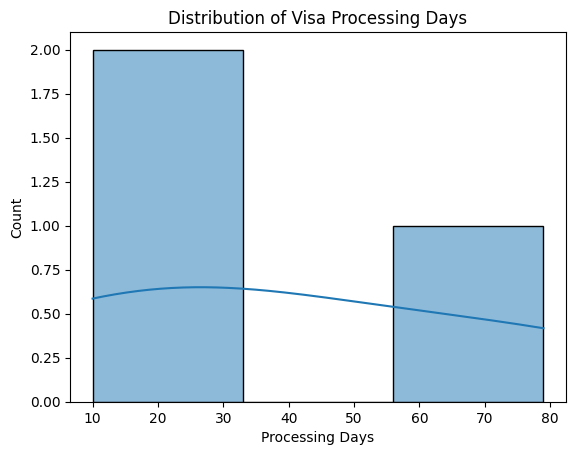

In [20]:
sns.histplot(df["processing_days"], kde=True) # kde uses smooth density curve
plt.title("Distribution of Visa Processing Days")
plt.xlabel("Processing Days")
plt.ylabel("Count")
plt.show()


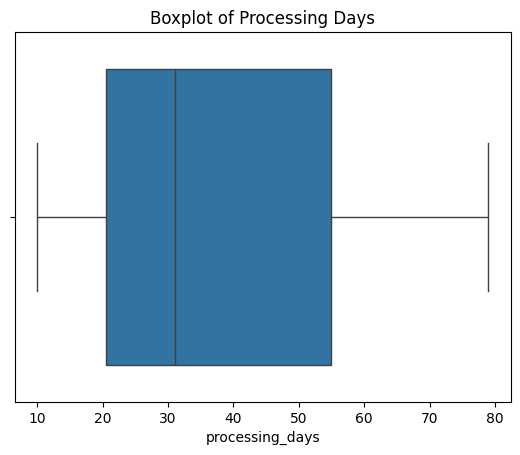

In [21]:
sns.boxplot(x=df["processing_days"]) # outlier detection- box plot
plt.title("Boxplot of Processing Days")
plt.show()


In [22]:
df["application_month"] = df["application_date"].dt.month
# preparing the data for correlation
print(df)

  application_date decision_date country visa_type  processing_days  \
0       2024-01-01    2024-02-01   India   Student               31   
1       2024-01-01    2024-03-20     USA   Tourist               79   
2       2024-03-10    2024-03-20      UK      Work               10   

   application_month  
0                  1  
1                  1  
2                  3  


In [23]:
corr_matrix = df[["processing_days", "application_month"]].corr() # calculates the correlation values
print(corr_matrix)

# range: +1-> strong +ve relationship, 0-> no relationship, -1 -> strong -ve relationship


                   processing_days  application_month
processing_days           1.000000          -0.734553
application_month        -0.734553           1.000000


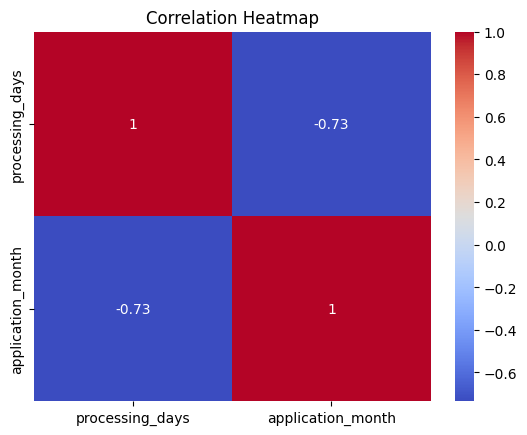

In [24]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm") # annot- shows nos inside the boxes, cmap- color scale for strnegth
plt.title("Correlation Heatmap")
plt.show()


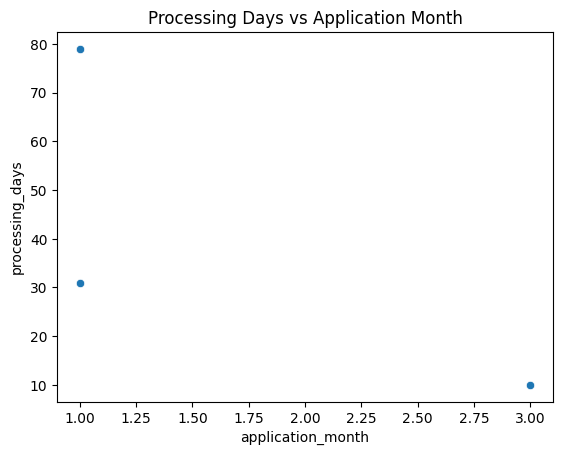

In [25]:
sns.scatterplot(
    x="application_month",
    y="processing_days",
    data=df
)
plt.title("Processing Days vs Application Month")
plt.show()


### FEATURE 1: Application Month

In [26]:
print(df[["application_date", "application_month"]])

  application_date  application_month
0       2024-01-01                  1
1       2024-01-01                  1
2       2024-03-10                  3


### FEATURE 2: Seasonal Index (Peak vs Off-Peak)

In [27]:
df["season"]= df["application_month"].apply(
    lambda x: "Peak" if x in [1,2,12] else "off-peak"
) # runs the logic row by row

print(df[["application_month", "season"]])

   application_month    season
0                  1      Peak
1                  1      Peak
2                  3  off-peak


### FEATURE 3: Country-Specific Average Processing Time

In [28]:
country_avg= df.groupby("country")["processing_days"].mean()
print(country_avg)

country
India    31.0
UK       10.0
USA      79.0
Name: processing_days, dtype: float64


In [29]:
df["country_avg"]= df["country"].map(country_avg)
print(df)

  application_date decision_date country visa_type  processing_days  \
0       2024-01-01    2024-02-01   India   Student               31   
1       2024-01-01    2024-03-20     USA   Tourist               79   
2       2024-03-10    2024-03-20      UK      Work               10   

   application_month    season  country_avg  
0                  1      Peak         31.0  
1                  1      Peak         79.0  
2                  3  off-peak         10.0  


### FEATURE 4: Visa-Type Average Processing Time (Aggregated Feature)

In [30]:
visa_avg= df.groupby("visa_type")["processing_days"].mean()
df["visa_avg"] = df["visa_type"].map(visa_avg)

print(df)

  application_date decision_date country visa_type  processing_days  \
0       2024-01-01    2024-02-01   India   Student               31   
1       2024-01-01    2024-03-20     USA   Tourist               79   
2       2024-03-10    2024-03-20      UK      Work               10   

   application_month    season  country_avg  visa_avg  
0                  1      Peak         31.0      31.0  
1                  1      Peak         79.0      79.0  
2                  3  off-peak         10.0      10.0  


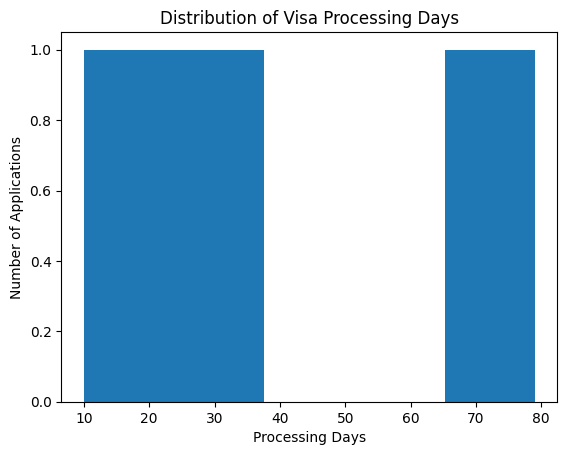

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["processing_days"], bins=5)

plt.title("Distribution of Visa Processing Days")
plt.xlabel("Processing Days")
plt.ylabel("Number of Applications")

plt.show()

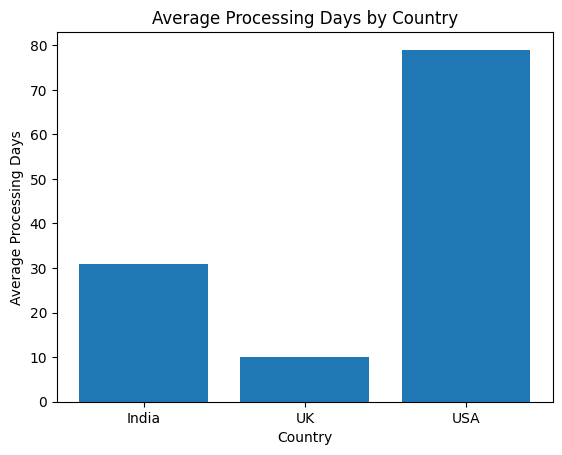

In [32]:
country_avg = df.groupby("country")["processing_days"].mean()

plt.figure()
plt.bar(country_avg.index, country_avg.values)

plt.title("Average Processing Days by Country")
plt.xlabel("Country")
plt.ylabel("Average Processing Days")

plt.show()


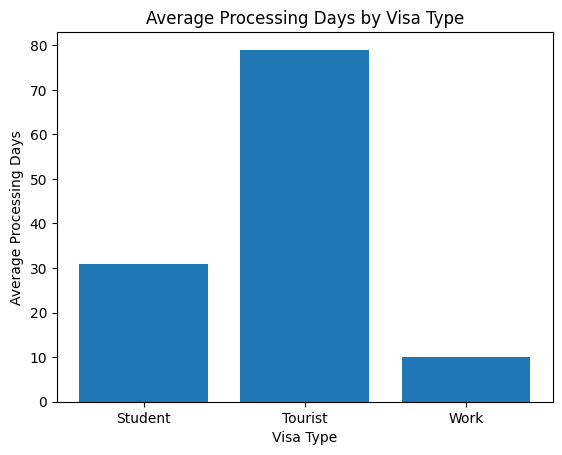

In [33]:
visa_avg = df.groupby("visa_type")["processing_days"].mean()

plt.figure()
plt.bar(visa_avg.index, visa_avg.values)

plt.title("Average Processing Days by Visa Type")
plt.xlabel("Visa Type")
plt.ylabel("Average Processing Days")

plt.show()


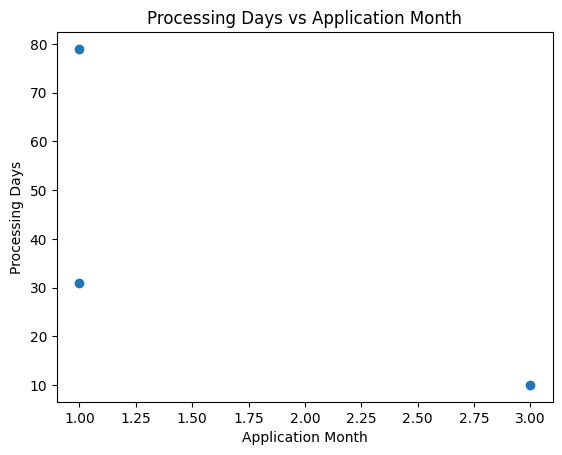

In [34]:
plt.figure()
plt.scatter(df["application_month"], df["processing_days"])

plt.title("Processing Days vs Application Month")
plt.xlabel("Application Month")
plt.ylabel("Processing Days")

plt.show()


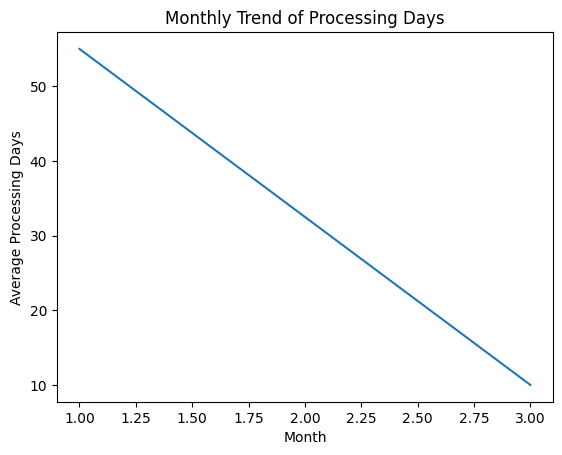

In [35]:
monthly_avg = df.groupby("application_month")["processing_days"].mean()

plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values)

plt.title("Monthly Trend of Processing Days")
plt.xlabel("Month")
plt.ylabel("Average Processing Days")

plt.show()


### Milestone 3

In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [37]:
data = {
    "application_date": pd.to_datetime(["2024-01-01", "2024-01-01", "2024-03-10"]),
    "decision_date": pd.to_datetime(["2024-02-01", "2024-03-20", "2024-03-20"]),
    "country": ["India", "Unknown", "UK"],
    "visa_type": ["Student", "Tourist", "Work"]
}

df = pd.DataFrame(data)
df["processing_days"] = (df["decision_date"] - df["application_date"]).dt.days


In [38]:
df["application_month"] = df["application_date"].dt.month

In [39]:
df_encoded = pd.get_dummies(df, columns=["country", "visa_type"], drop_first=True)


In [40]:
X = df_encoded.drop(
    columns=["processing_days", "application_date", "decision_date"]
)
y = df_encoded["processing_days"]


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [42]:
model= LinearRegression()

In [43]:
model.fit(X_train, y_train)# this is where the learning  happens

LinearRegression()

In [44]:
y_pred = model.predict(X_test)

In [45]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 30.75
RMSE: 30.75


### Continue with the Random Forest- once you introduce the model to rf, fit the model, train the model, and evaluate the model accordingly



In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [55]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [56]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 21.78
Random Forest RMSE: 21.78


In [57]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [61]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=2,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [62]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=2, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_absolute_error')

In [63]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [64]:
best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(X_test)

In [65]:
best_mae = mean_absolute_error(y_test, best_predictions)
best_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))

print("Tuned Random Forest MAE:", best_mae)
print("Tuned Random Forest RMSE:", best_rmse)

Tuned Random Forest MAE: 23.159999999999997
Tuned Random Forest RMSE: 23.159999999999997
